# Do Tolstoy and Hugo differ in their psychological representation of characters?

**Author**: Alexey Kovrev & Ayşegül Ada Benhür

Corrections:

**Date**: May 2026

## 1. Library import

In [16]:
import pandas as pd
import ast
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import scipy.stats as stats

## 2. Directed Acyclic Graph

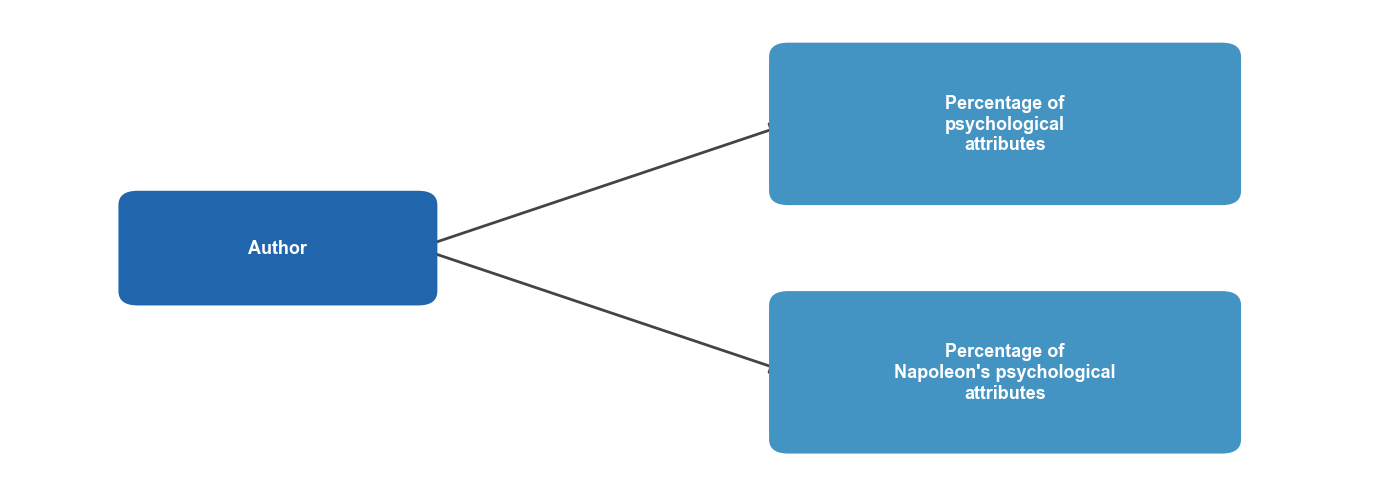

In [17]:
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(-0.3, 10.5)
ax.set_ylim(0, 5)
ax.axis('off')

NODE_DEFS = [
    ("Author",                                               1.8, 2.5, 2.2, 0.9, "#2166AC"),
    ("Percentage of\npsychological\nattributes",             7.5, 3.8, 3.4, 1.4, "#4393C3"),
    ("Percentage of\nNapoleon's psychological\nattributes",  7.5, 1.2, 3.4, 1.4, "#4393C3"),
]

node_centers = {}
for label, cx, cy, w, h, color in NODE_DEFS:
    ax.add_patch(FancyBboxPatch(
        (cx - w / 2, cy - h / 2), w, h,
        boxstyle="round,pad=0.15",
        facecolor=color, edgecolor="none", zorder=3,
    ))
    ax.text(cx, cy, label,
            ha="center", va="center", fontsize=13,
            color="white", fontweight="bold", fontfamily="sans-serif",
            multialignment="center", zorder=4)
    node_centers[label] = (cx, cy, w, h)

EDGES = [
    ("Author", "Percentage of\npsychological\nattributes"),
    ("Author", "Percentage of\nNapoleon's psychological\nattributes"),
]

for src, dst in EDGES:
    sx, sy, sw, _ = node_centers[src]
    dx, dy, dw, _ = node_centers[dst]
    ax.annotate("",
                xy=(dx - dw / 2, dy), xytext=(sx + sw / 2, sy),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color="#444444", lw=2.0, mutation_scale=22,
                ),
                zorder=2)

plt.tight_layout(pad=0.5)
plt.show()

## 3. Data import

In [18]:
df_war_and_peace = pd.read_csv("data/war_and_peace.csv")

In [19]:
df_war_and_peace

,Unnamed: 0,tome,chapitre,section,id,count,gender,number,mentions,agent,...,existence_state,human_relations,motion,not_a_valid_character_attribute,perception,personality_traits,physical_objects,physical_traits,possession,sociological
0,0,TOME_I,CHAPITRE_PREMIER,I,0,"{'occurrence': 131, 'mention_ratio': 0.3754}","{'ratio': 0.374, 'inference': {'Male': 0.88, '...","{'ratio': 0.7252000000000001, 'inference': {'S...","{'proper': [{'n': 'au prince basile', 'c': 1},...","[{'w': 'cesser', 'i': 34}, {'w': 'dire', 'i': ...",...,2,4,6,9,4,6,1,0,0,7
1,1,TOME_I,CHAPITRE_PREMIER,I,1,"{'occurrence': 35, 'mention_ratio': 0.1003}","{'ratio': 0.4857, 'inference': {'Male': 0.24, ...","{'ratio': 0.8857, 'inference': {'Singular': 1....","{'proper': [{'n': 'anna pavlovna schérer', 'c'...","[{'w': 'dire', 'i': 9}, {'w': 'déclarer', 'i':...",...,4,6,1,2,0,2,0,0,0,4
2,2,TOME_I,CHAPITRE_PREMIER,I,2,"{'occurrence': 33, 'mention_ratio': 0.0946}","{'ratio': 0.2121, 'inference': {'Male': 0.5700...","{'ratio': 0.7879, 'inference': {'Singular': 1....","{'proper': [{'n': 'anna pavlovna', 'c': 1}], '...","[{'w': 'croire', 'i': 897}, {'w': 'tenir', 'i'...",...,0,1,2,1,2,0,0,0,0,0
3,3,TOME_I,CHAPITRE_PREMIER,I,3,"{'occurrence': 15, 'mention_ratio': 0.04300000...","{'ratio': 0.2, 'inference': {'Male': 1.0, 'Fem...","{'ratio': 0.8667, 'inference': {'Singular': 1....","{'proper': [{'n': 'le prince basile', 'c': 1},...","[{'w': 'dire', 'i': 2128}, {'w': 'indiquer', '...",...,0,2,0,0,0,0,0,0,1,0
4,4,TOME_I,CHAPITRE_PREMIER,I,4,"{'occurrence': 12, 'mention_ratio': 0.0344}","{'ratio': 0.5, 'inference': {'Male': 0.0, 'Fem...","{'ratio': 1.0, 'inference': {'Singular': 1.0, ...","{'proper': [{'n': 'anna pavlovna', 'c': 1}], '...","[{'w': 'continuer', 'i': 1638}, {'w': 'rapproc...",...,0,0,2,1,2,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7869,7869,TOME_III,CHAPITRE_VI,VI,100,"{'occurrence': 2, 'mention_ratio': 0.0019}","{'ratio': 1.0, 'inference': {'Male': 1.0, 'Fem...","{'ratio': 1.0, 'inference': {'Singular': 1.0, ...","{'proper': [{'n': 'pierre', 'c': 1}], 'common'...",[],...,0,0,0,0,0,0,0,0,0,0
7870,7870,TOME_III,CHAPITRE_VI,VI,101,"{'occurrence': 2, 'mention_ratio': 0.0019}","{'ratio': 0.5, 'inference': {'Male': 1.0, 'Fem...","{'ratio': 0.5, 'inference': {'Singular': 1.0, ...","{'proper': [{'n': 'pierre', 'c': 1}], 'common'...","[{'w': 'parler', 'i': 5608}]",...,0,0,0,0,0,0,0,0,0,0
7871,7871,TOME_III,CHAPITRE_VI,VI,102,"{'occurrence': 2, 'mention_ratio': 0.0019}","{'ratio': 0.5, 'inference': {'Male': 1.0, 'Fem...","{'ratio': 1.0, 'inference': {'Singular': 1.0, ...","{'proper': [{'n': 'pierre', 'c': 1}], 'common'...","[{'w': 'revenir', 'i': 5761}]",...,0,0,0,0,0,0,0,0,0,0
7872,7872,TOME_III,CHAPITRE_VI,VI,103,"{'occurrence': 2, 'mention_ratio': 0.0019}","{'ratio': 0.5, 'inference': {'Male': 1.0, 'Fem...","{'ratio': 0.5, 'inference': {'Singular': 1.0, ...","{'proper': [{'n': 'dessalles', 'c': 1}], 'comm...","[{'w': 'demander', 'i': 6545}]",...,0,0,0,0,0,0,0,0,0,0


In [20]:
df_les_miserables = pd.read_csv("data/les_miserables.csv")

In [21]:
df_les_miserables

,Unnamed: 0,volume,livre,chapitre,id,count,gender,number,mentions,agent,...,existence_state,human_relations,motion,not_a_valid_character_attribute,perception,personality_traits,physical_objects,physical_traits,possession,sociological
0,0,hugo_les_miserables_cosette,Livre_premier_Waterloo,Chapitre_I_Ce_quon_rencontre_en_venant_d,0.0,"{'occurrence': 23, 'mention_ratio': 0.7931}","{'ratio': 0.7826000000000001, 'inference': {'M...","{'ratio': 0.8696, 'inference': {'Singular': 1....","{'proper': [], 'common': [{'n': 'le passant', ...","[{'w': 'raconter', 'i': 30}, {'w': 'arriver', ...",...,1,0,9,1,7,0,0,0,0,0
1,1,hugo_les_miserables_cosette,Livre_premier_Waterloo,Chapitre_I_Ce_quon_rencontre_en_venant_d,1.0,"{'occurrence': 5, 'mention_ratio': 0.1724}","{'ratio': 1.0, 'inference': {'Male': 0.0, 'Fem...","{'ratio': 1.0, 'inference': {'Singular': 1.0, ...","{'proper': [], 'common': [{'n': 'une paysanne'...","[{'w': 'sortir', 'i': 606}, {'w': 'voir', 'i':...",...,0,0,1,0,2,0,0,0,0,0
2,2,hugo_les_miserables_cosette,Livre_premier_Waterloo,Chapitre_I_Ce_quon_rencontre_en_venant_de_Nive...,0.0,"{'occurrence': 23, 'mention_ratio': 0.7931}","{'ratio': 0.7826000000000001, 'inference': {'M...","{'ratio': 0.8696, 'inference': {'Singular': 1....","{'proper': [], 'common': [{'n': 'le passant', ...","[{'w': 'raconter', 'i': 30}, {'w': 'arriver', ...",...,1,0,9,1,7,0,0,0,0,0
3,3,hugo_les_miserables_cosette,Livre_premier_Waterloo,Chapitre_I_Ce_quon_rencontre_en_venant_de_Nive...,1.0,"{'occurrence': 5, 'mention_ratio': 0.1724}","{'ratio': 1.0, 'inference': {'Male': 0.0, 'Fem...","{'ratio': 1.0, 'inference': {'Singular': 1.0, ...","{'proper': [], 'common': [{'n': 'une paysanne'...","[{'w': 'sortir', 'i': 606}, {'w': 'voir', 'i':...",...,0,0,1,0,2,0,0,0,0,0
4,4,hugo_les_miserables_cosette,Livre_premier_Waterloo,Chapitre_II_Hougomont,0.0,"{'occurrence': 15, 'mention_ratio': 0.121}","{'ratio': 0.4, 'inference': {'Male': 1.0, 'Fem...","{'ratio': 0.7333000000000001, 'inference': {'S...","{'proper': [{'n': 'le sous-lieutenant legros',...","[{'w': 'tenir', 'i': 1406}, {'w': 'tirer', 'i'...",...,1,2,1,2,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5458,5458,hugo_les_miserables_marius,Livre_huitieme_Le_mauvais_pauvre,Chapitre_XXI_On_devrait_toujours_commenc,28.0,"{'occurrence': 2, 'mention_ratio': 0.0095}","{'ratio': 0, 'inference': {'Male': 0, 'Female'...","{'ratio': 0.5, 'inference': {'Singular': 1.0, ...","{'proper': [], 'common': [{'n': 'l’ homme à la...",[],...,0,0,0,0,0,0,0,0,0,0
5459,5459,hugo_les_miserables_marius,Livre_huitieme_Le_mauvais_pauvre,Chapitre_XXI_On_devrait_toujours_commenc,29.0,"{'occurrence': 2, 'mention_ratio': 0.0095}","{'ratio': 0, 'inference': {'Male': 0, 'Female'...","{'ratio': 1.0, 'inference': {'Singular': 1.0, ...","{'proper': [{'n': 'javert', 'c': 1}], 'common'...",[],...,0,0,0,0,0,0,0,0,0,0
5460,5460,hugo_les_miserables_marius,Livre_huitieme_Le_mauvais_pauvre,Chapitre_XXII_Le_petit_qui_criait_au_tom,0.0,"{'occurrence': 42, 'mention_ratio': 0.5915}","{'ratio': 0.4048, 'inference': {'Male': 1.0, '...","{'ratio': 0.8571000000000001, 'inference': {'S...","{'proper': [{'n': 'mame burgon', 'c': 1}], 'co...","[{'w': 'crier', 'i': 6}, {'w': 'sembler', 'i':...",...,0,2,7,3,7,0,1,2,0,0
5461,5461,hugo_les_miserables_marius,Livre_huitieme_Le_mauvais_pauvre,Chapitre_XXII_Le_petit_qui_criait_au_tom,1.0,"{'occurrence': 23, 'mention_ratio': 0.3239}","{'ratio': 0.6087, 'inference': {'Male': 0.0, '...","{'ratio': 1.0, 'inference': {'Singular': 1.0, ...","{'proper': [], 'common': [{'n': 'la vieille', ...","[{'w': 'fouiller', 'i': 104}, {'w': 'redresser...",...,0,2,3,1,5,0,0,0,0,1


## 4. Data manipulation

In [22]:
# Manipulation df_war_and_peace

# Creating author column
df_war_and_peace["author"] = "Tolstoy"

# Counting the total number of attributes a character have
df_war_and_peace["attributes_number"] = df_war_and_peace.loc[:, "action" : "sociological"].sum(axis=1)

# Dropping characters with 0 attributes
df_war_and_peace.dropna(subset=["attributes_number"], inplace=True)
df_war_and_peace = df_war_and_peace[df_war_and_peace["attributes_number"] > 0]

# Counting the number of attributes that belong to the Psychological hyperclass (affect/emotion, capability/obligation, cognition, perception, personality traits) a character have
df_war_and_peace["psychological_attributes"] = df_war_and_peace[["perception", "personality_traits", "affect_emotion", "capability_obligation", "cognition"]].sum(axis=1)

# Calculating the ration of psychological attributes to the total number of attributes
df_war_and_peace["psychological_attributes_ratio"] = df_war_and_peace["psychological_attributes"] / df_war_and_peace["attributes_number"]

# Parsing mentions and simplifying to the first proper name, or None if no proper name exists
df_war_and_peace["mentions"] = df_war_and_peace["mentions"].map(
    lambda x: d["proper"][0]["n"]
    if (d := ast.literal_eval(x) if isinstance(x, str) else x).get("proper")
    else None
)

# Dropping characters with no proper name
df_war_and_peace.dropna(subset=["mentions"], inplace=True)

# Set of proper names referring to Napoleon
wp_napoleon_dict = {
    "napoléon", "bonaparte", "buonaparte",
    "l' empereur napoléon", "du grand empereur napoléon",
    "le général bonaparte", "le petit bonaparte",
    "le petit napoléon", "l' heureux napoléon",
    "notre cher bonaparte",
    "m. buonaparte", "un certain napoléon",
    "l' usurpateur", "votre goujat d' empereur",
}

# Creating a column to mark that character is Napoleon
df_war_and_peace["is_napoleon"] = df_war_and_peace["mentions"].isin(wp_napoleon_dict)

# Dropping unused columns
df_war_and_peace.drop(columns=["Unnamed: 0", "tome", "chapitre", "section", "id", "count", "number", "gender", "agent", "patient", "mod", "poss"], inplace=True)

In [23]:
# Manipulating df_les_miserables

# Creating author column
df_les_miserables["author"] = "Hugo"

# Counting the total number of attributes a character have
df_les_miserables["attributes_number"] = df_les_miserables.loc[:, "action" : "sociological"].sum(axis=1)

# Dropping characters with 0 attributes
df_les_miserables.dropna(subset=["attributes_number"], inplace=True)
df_les_miserables = df_les_miserables[df_les_miserables["attributes_number"] > 0]

# Counting the number of attributes that belong to the Psychological hyperclass (affect/emotion, capability/obligation, cognition, perception, personality traits) a character have
df_les_miserables["psychological_attributes"] = df_les_miserables[["perception", "personality_traits", "affect_emotion", "capability_obligation", "cognition"]].sum(axis=1)

# Calculating the ration of psychological attributes to the total number of attributes
df_les_miserables["psychological_attributes_ratio"] = df_les_miserables["psychological_attributes"] / df_les_miserables["attributes_number"]

# Parsing mentions and simplifying to the first proper name, or None if no proper name exists
df_les_miserables["mentions"] = df_les_miserables["mentions"].map(
    lambda x: d["proper"][0]["n"]
    if (d := ast.literal_eval(x) if isinstance(x, str) else x).get("proper")
    else None
)

# Dropping characters with no proper name
df_les_miserables.dropna(subset=["mentions"], inplace=True)

# Set of proper names referring to Napoleon
lm_napoleon_dict = {
    "napoléon", "bonaparte", "buonaparte",
    "l' emp · buonaparte", "l' empereur",
    "le maître de l' europe", "le continuateur de charlemagne",
    "le colosse", "cet homme vaste",
    "l' homme prédestiné", "le dernier césar",
    "un colonel de bonaparte", "le ministre de l' intérieur · napoléon",
}

# Creating a column to mark that character is Napoleon
df_les_miserables["is_napoleon"] = df_les_miserables["mentions"].isin(lm_napoleon_dict)

# Dropping unused columns
df_les_miserables.drop(columns=["Unnamed: 0", "volume", "livre", "chapitre", "id", "count", "number", "gender", "agent", "patient", "mod", "poss"], inplace=True)

In [24]:
# Merging two dataframes and applying minimum attributes threshold
df_tolstoy_hugo = pd.concat([df_war_and_peace, df_les_miserables], ignore_index=True)
# Keeping only character entities that have at least 8 attributes (value of percentile = 0.75) to keep only characters that have enough attributes in a chapter and not just occasional mentions
df_tolstoy_hugo = df_tolstoy_hugo[df_tolstoy_hugo["attributes_number"] >= 8]

In [25]:
df_tolstoy_hugo

,mentions,action,affect_emotion,body_parts,capability_obligation,cognition,communication,environment,existence_state,human_relations,...,personality_traits,physical_objects,physical_traits,possession,sociological,author,attributes_number,psychological_attributes,psychological_attributes_ratio,is_napoleon
0,au prince basile,6,3,7,1,17,17,0,2,4,...,6,1,0,0,7,Tolstoy,90,31,0.344444,False
1,anna pavlovna schérer,0,6,0,0,2,3,0,4,6,...,2,0,0,0,4,Tolstoy,30,10,0.333333,False
2,anna pavlovna,1,4,0,0,6,3,0,0,1,...,0,0,0,0,0,Tolstoy,20,12,0.600000,False
3,le prince basile,0,1,0,0,3,3,0,0,2,...,0,0,0,1,0,Tolstoy,10,4,0.400000,False
4,anna pavlovna,0,2,1,0,1,3,0,0,0,...,1,0,0,0,0,Tolstoy,13,6,0.461538,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8744,javert,4,0,0,0,0,2,0,0,0,...,0,0,0,0,0,Hugo,17,5,0.294118,False
8745,la thénardier,3,1,4,0,0,1,0,0,2,...,1,2,0,0,0,Hugo,17,2,0.117647,False
8746,javert,1,0,2,0,0,3,0,1,0,...,0,1,0,0,0,Hugo,10,0,0.000000,False
8747,javert,1,2,0,0,0,1,0,0,0,...,0,0,0,0,0,Hugo,9,2,0.222222,False


## 5. Data description

In [26]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import os

# Explicitly load DejaVu Sans from matplotlib's bundled fonts.
# This bypasses the font cache entirely — works regardless of IDE/kernel/environment.
_ttf_dir = os.path.join(mpl.get_data_path(), 'fonts', 'ttf')
for _variant in ('DejaVuSans.ttf', 'DejaVuSans-Bold.ttf', 'DejaVuSans-Oblique.ttf'):
    _path = os.path.join(_ttf_dir, _variant)
    if os.path.exists(_path):
        fm.fontManager.addfont(_path)

plt.rcParams.update({
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['DejaVu Sans'],
    'font.size'         : 16,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : 'black',
    'axes.labelcolor'   : 'black',
    'xtick.color'       : 'black',
    'ytick.color'       : 'black',
    'text.color'        : 'black',
    'xtick.bottom'      : True,
    'ytick.left'        : True,
    'xtick.labelbottom' : True,
    'ytick.labelleft'   : True,
})

PALETTE    = {"Tolstoy": "#2166AC", "Hugo": "#D6604D"}
HIST_COLOR = "#4393C3"


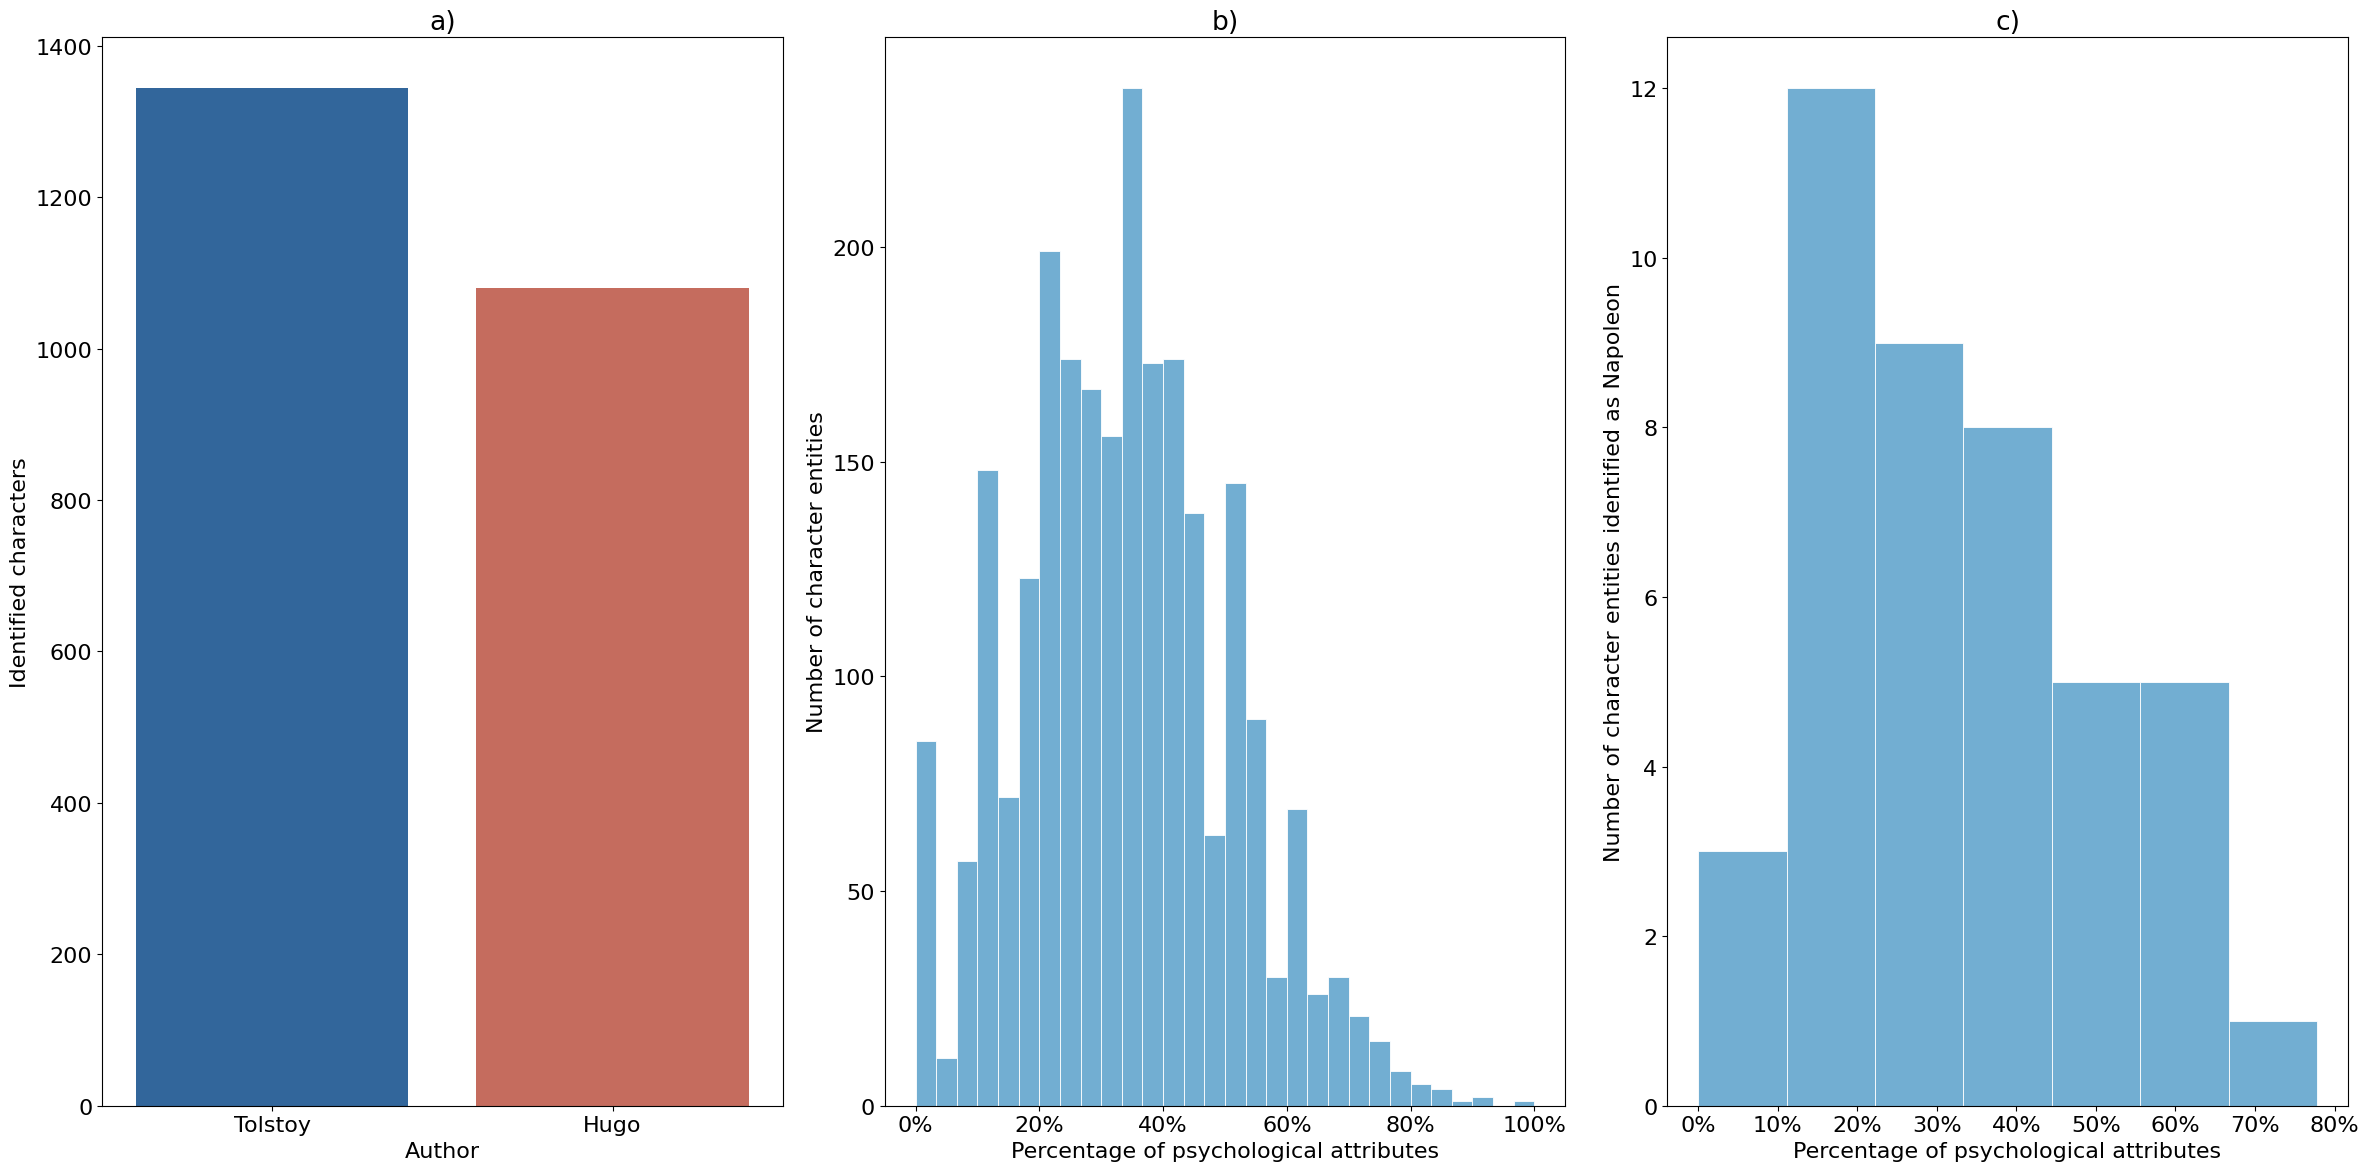

In [27]:
fig1, axes1 = plt.subplots(1, 3, figsize=(24, 12))

# Figure 1.a: Barplot of Tolstoy's and Hugo's character entities
sns.countplot(data=df_tolstoy_hugo, x="author", hue="author",
              palette=PALETTE, legend=False, ax=axes1[0])
axes1[0].set_xlabel("Author")
axes1[0].set_ylabel("Identified characters")
axes1[0].set_title("a)")

# Figure 1.b: Histplot of percentage of psychological attributes
sns.histplot(data=df_tolstoy_hugo, x="psychological_attributes_ratio",
             color=HIST_COLOR, edgecolor="white", linewidth=0.6, ax=axes1[1])
axes1[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes1[1].set_ylabel("Number of character entities")
axes1[1].set_xlabel("Percentage of psychological attributes")
axes1[1].set_title("b)")

# Figure 1.c: Histplot of Napoleon's percentage of psychological attributes
sns.histplot(data=df_tolstoy_hugo[df_tolstoy_hugo["is_napoleon"] == True],
             x="psychological_attributes_ratio",
             color=HIST_COLOR, edgecolor="white", linewidth=0.6, ax=axes1[2])
axes1[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes1[2].set_ylabel("Number of character entities identified as Napoleon")
axes1[2].set_xlabel("Percentage of psychological attributes")
axes1[2].set_title("c)")

plt.tight_layout()
plt.show()

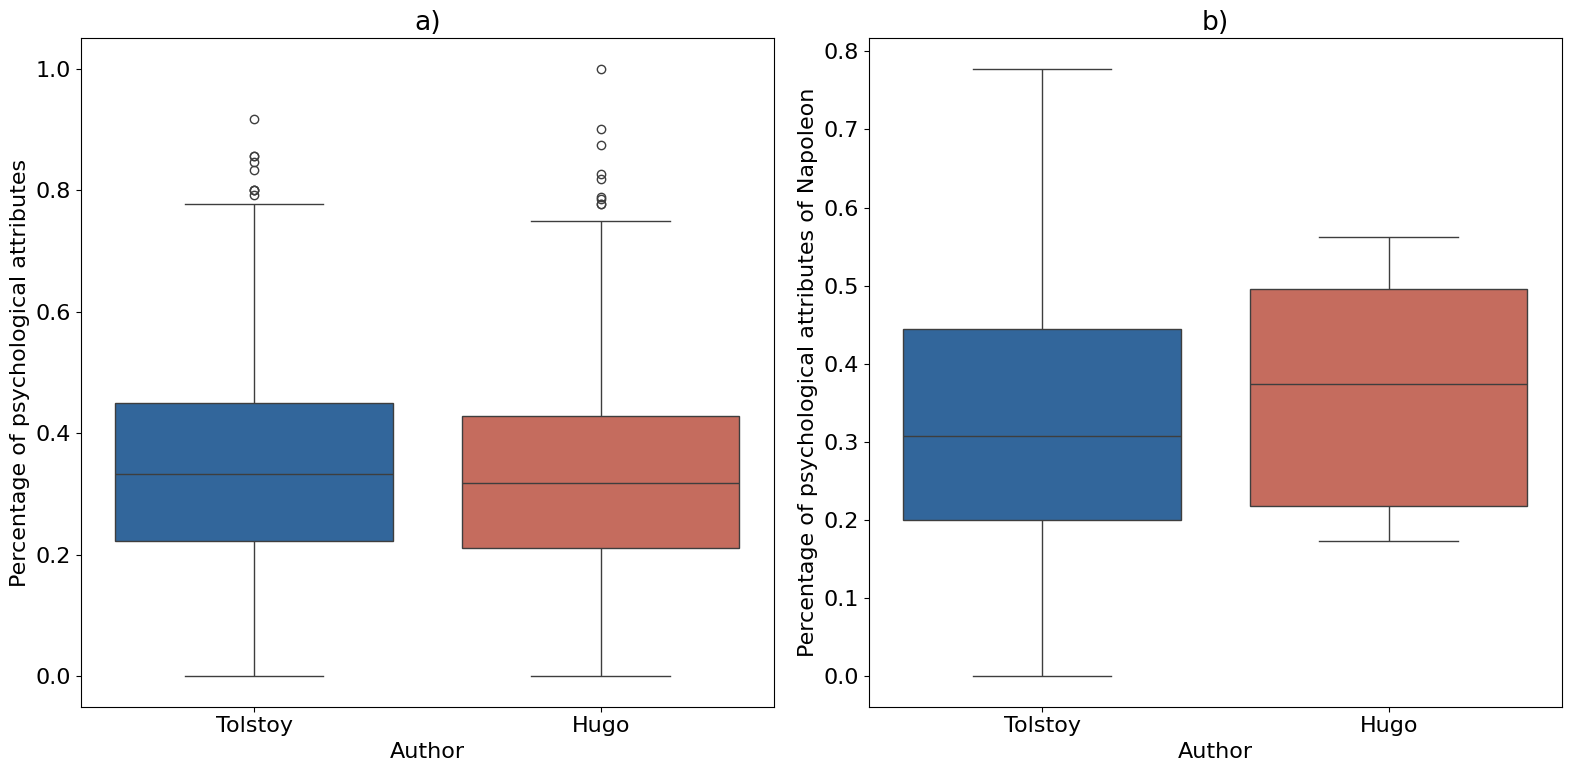

In [28]:
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 8))

# Figure 2.a: Boxplot of the percentage of psychological attributes depending on author
sns.boxplot(data=df_tolstoy_hugo, x="author", y="psychological_attributes_ratio",
            hue="author", palette=PALETTE, legend=False, ax=axes2[0])
axes2[0].set_xlabel("Author")
axes2[0].set_ylabel("Percentage of psychological attributes")
axes2[0].set_title("a)")

# Figure 2.b: Boxplot of Napoleon's percentage of psychological attributes depending on author
df_tolstoy_hugo_napoleon = df_tolstoy_hugo[df_tolstoy_hugo["is_napoleon"] == True]
sns.boxplot(data=df_tolstoy_hugo_napoleon, x="author", y="psychological_attributes_ratio",
            hue="author", palette=PALETTE, legend=False, ax=axes2[1])
axes2[1].set_xlabel("Author")
axes2[1].set_ylabel("Percentage of psychological attributes of Napoleon")
axes2[1].set_title("b)")

plt.tight_layout()
plt.show()

## 6. Data modeling

### 6.1 T-test of the difference of percentage of psychological attributes depending on the author

In [29]:
percent_psy_attributes_tolstoy = df_tolstoy_hugo[df_tolstoy_hugo["author"] == "Tolstoy"]["psychological_attributes_ratio"]
percent_psy_attributes_hugo = df_tolstoy_hugo[df_tolstoy_hugo["author"] == "Hugo"]["psychological_attributes_ratio"]

t_statistic, p_value = stats.ttest_ind(percent_psy_attributes_tolstoy, percent_psy_attributes_hugo)

print(f"t-stat: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")


t-stat: 2.9629
p-value: 0.0031


### 6.2 T-test of the difference of percentage of psychological attributes of Napoleon depending on the author

In [30]:
percent_psy_attributes_tolstoy = df_tolstoy_hugo[
    (df_tolstoy_hugo["author"] == "Tolstoy") & (df_tolstoy_hugo["is_napoleon"] == True)
]["psychological_attributes_ratio"]

percent_psy_attributes_hugo = df_tolstoy_hugo[
    (df_tolstoy_hugo["author"] == "Hugo") & (df_tolstoy_hugo["is_napoleon"] == True)
]["psychological_attributes_ratio"]

t_statistic, p_value = stats.ttest_ind(percent_psy_attributes_tolstoy, percent_psy_attributes_hugo)

print(f"t-stat: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")


t-stat: -0.6358
p-value: 0.5284
